# Pneumonia Detection from Chest X-Rays


## 1. Setup and imports


In [1]:
import os
import json
import zipfile
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import joblib
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight

from skimage.feature import hog

# Set random seeds for reproducibility.
SEED = 19999
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("GPU available:", tf.config.list_physical_devices("GPU"))


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Due to the use of Google Colab and the size and amount of files used here, I mount my drive to source all input locally.
# However this is in session so you must adjust to your own setup.
from google.colab import drive
drive.mount('/content/drive')

DRIVE_BASE = Path("/content/drive/MyDrive/MLfinalassignment")
DRIVE_BASE.mkdir(parents=True, exist_ok=True)
print(f"Drive base: {DRIVE_BASE}")


Mounted at /content/drive
Drive base: /content/drive/MyDrive/MLfinalassignment


In [3]:
# Output paths for cached model assets, stored on Google Drive.
MODEL_ASSETS_OUTPUT = DRIVE_BASE / "archive/_run_artifacts_run1/models"
MODEL_ASSETS_OUTPUT.mkdir(parents=True, exist_ok=True)
CNN_PATH = MODEL_ASSETS_OUTPUT / "cnn_resnet50_v3.keras"
SVM_PATH = MODEL_ASSETS_OUTPUT / "svm_rbf_v3.pkl"
SCALER_PATH = MODEL_ASSETS_OUTPUT / "scaler_v3.pkl"

print(f"Model assets dir: {MODEL_ASSETS_OUTPUT}")
print(f"  CNN:    {'FOUND' if CNN_PATH.exists() else 'missing'} ({CNN_PATH.name})")
print(f"  SVM:    {'FOUND' if SVM_PATH.exists() else 'missing'} ({SVM_PATH.name})")
print(f"  Scaler: {'FOUND' if SCALER_PATH.exists() else 'missing'} ({SCALER_PATH.name})")


Model assets dir: /content/drive/MyDrive/MLfinalassignment/archive/_run_artifacts_run1/models
  CNN:    FOUND (cnn_resnet50_v3.keras)
  SVM:    FOUND (svm_rbf_v3.pkl)
  Scaler: FOUND (scaler_v3.pkl)


## Support functions


In [4]:
# Reusable functions: HOG extraction, the confusion matrix and the subgroup metrics.

def extract_hog_features(image_path, size=128):
    """Grayscale + resize + scale to [0,1], then HOG features."""
    img = Image.open(image_path).convert("L").resize((size, size))
    img = np.array(img) / 255.0
    return hog(img, orientations=9, pixels_per_cell=(8, 8),
               cells_per_block=(2, 2), block_norm="L2-Hys")


def plot_confusion_matrix(model_name, y_true, y_pred, save_path=None):
    """Plot 2x2 confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["NORMAL", "PNEUMONIA"],
                yticklabels=["NORMAL", "PNEUMONIA"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()


def compute_subgroup_metrics(df_slice, subgroup_name):
    """SVM and CNN macro-F1 and pneumonia recall for a slice."""
    return {
        "Subgroup": subgroup_name,
        "n": len(df_slice),
        "SVM macro-F1": f1_score(df_slice["label"], df_slice["svm_pred"],
                                 average="macro", zero_division=0),
        "CNN macro-F1": f1_score(df_slice["label"], df_slice["cnn_pred"],
                                 average="macro", zero_division=0),
        "SVM PNEU recall": recall_score(df_slice["label"], df_slice["svm_pred"],
                                         pos_label=1, zero_division=0),
        "CNN PNEU recall": recall_score(df_slice["label"], df_slice["cnn_pred"],
                                         pos_label=1, zero_division=0),
    }


## 2. Dataset


In [5]:
# The X-ray zip file dataset is located in Google Drive, so thus unzip and check content for each run, no download.
# Can be adjusted to your own setup to source the location of the dataset.
import shutil

XRAY_ZIP = DRIVE_BASE / "chest_xray.zip"
DATA_DIR    = Path("/content/chest_xray")

if DATA_DIR.exists() and (DATA_DIR / "train").exists() and (DATA_DIR / "test").exists():
    print(f"Dataset already extracted at {DATA_DIR}")
else:
    if not XRAY_ZIP.exists():
        raise FileNotFoundError(
            f"chest_xray.zip not found at {XRAY_ZIP}. "
            f"Upload it to {DRIVE_BASE} once and re-run."
        )
    print(f"Extracting {XRAY_ZIP} to {DATA_DIR.parent}...")
    with zipfile.ZipFile(XRAY_ZIP, "r") as zf:
        zf.extractall("/content")
    print("Done.")

# Original X-ray dataset has a particular nested structure so we work on it to make it easier for usage.
# Note: ideal would be to modify and leave it ready so thus this logic is not part of the ML notebook,
# however I decided to keep the original zip intact for traceability and full reproducibility at the cost
# of including the logic needed for files to be easier to use by our ML notebook.
nested = DATA_DIR / "chest_xray"
if nested.exists():
    if (DATA_DIR / "train").exists() and (DATA_DIR / "test").exists():
        print(f"Removing duplicate nested directory {nested}")
        shutil.rmtree(nested)
    else:
        print(f"Flattening nested directory {nested} -> {DATA_DIR}")
        for sub in nested.iterdir():
            shutil.move(str(sub), str(DATA_DIR / sub.name))
        nested.rmdir()

print("Dataset folders:", sorted(p.name for p in DATA_DIR.iterdir() if p.is_dir()))


Extracting /content/drive/MyDrive/MLfinalassignment/chest_xray.zip to /content...
Done.
Removing duplicate nested directory /content/chest_xray/chest_xray
Dataset folders: ['__MACOSX', 'test', 'train', 'val']


## 3. Exploratory data analysis


       NORMAL  PNEUMONIA
train    1341       3875
val         8          8
test      234        390


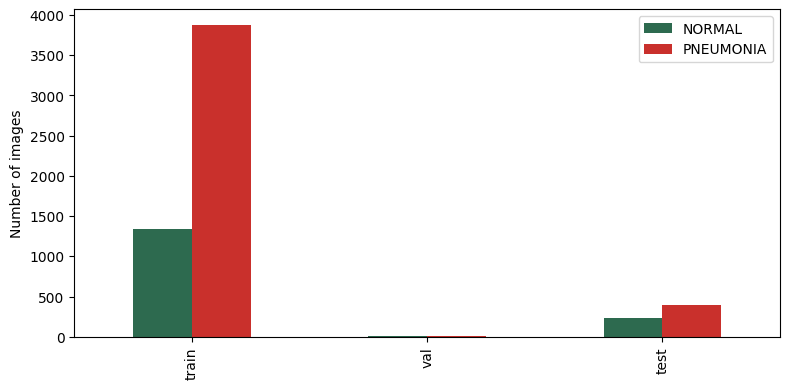

In [6]:
# Count how many NORMAL and PNEUMONIA images are in each split and print table for quick reference.
# Objective is to show the class imbalance.
counts = {}
for split in ["train", "val", "test"]:
    counts[split] = {
        "NORMAL":    len(list((DATA_DIR / split / "NORMAL").glob("*.jpeg"))),
        "PNEUMONIA": len(list((DATA_DIR / split / "PNEUMONIA").glob("*.jpeg"))),
    }
counts_df = pd.DataFrame(counts).T
print(counts_df)

# Produce bar charts for class balance.
fig, ax = plt.subplots(figsize=(8, 4))
counts_df.plot(kind="bar", ax=ax, color=["#2D6A4F", "#C9302C"])
ax.set_ylabel("Number of images")
plt.tight_layout()
plt.savefig("class_balance.png", dpi=180, bbox_inches="tight")
plt.show()


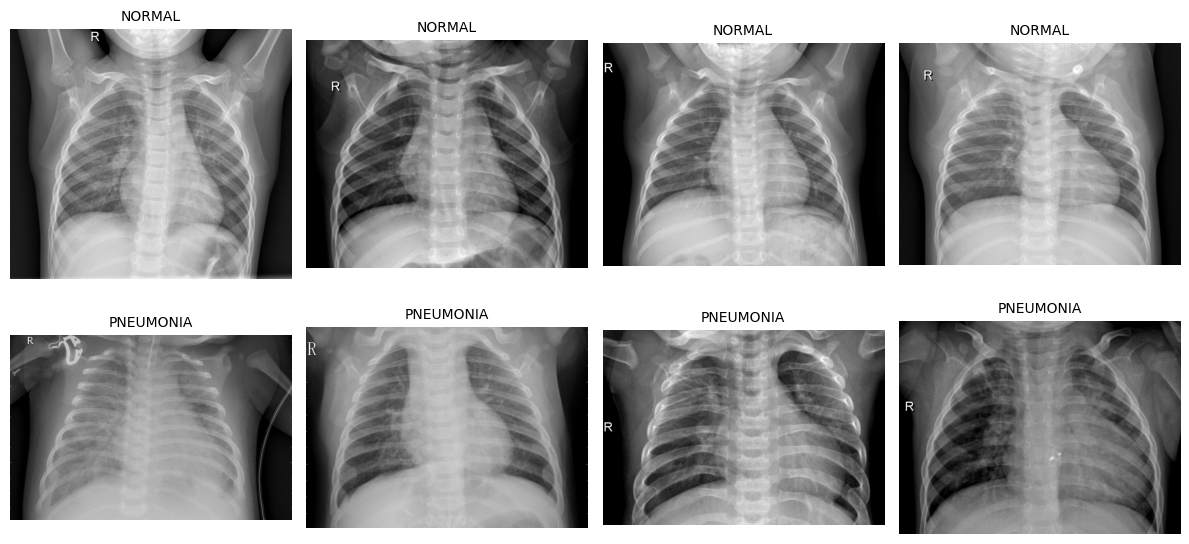

In [7]:
# Display sample X-ray images, one row per class. Useful for presentation deck.
# Additional images for evaluation could be inserted here, and later decide if it makes it to the final
# presentation or not based on the deck flow and narrative. For the moment I keep it as useful for small check.
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for row, cls in enumerate(["NORMAL", "PNEUMONIA"]):
    paths = sorted((DATA_DIR / "train" / cls).glob("*.jpeg"))[:4]
    for col, p in enumerate(paths):
        axes[row, col].imshow(Image.open(p), cmap="gray")
        axes[row, col].set_title(cls, fontsize=10)
        axes[row, col].axis("off")
plt.tight_layout()
plt.savefig("sample_xrays.png", dpi=180, bbox_inches="tight")
plt.show()


## 4. Train / validation / test split


In [8]:
# Build a DataFrame per split with image paths and labels for later use in modelling.
train_rows = []
for cls, label in [("NORMAL", 0), ("PNEUMONIA", 1)]:
    for p in sorted((DATA_DIR / "train" / cls).glob("*.jpeg")):
        train_rows.append({"path": str(p), "label": label})
val_rows = []
for cls, label in [("NORMAL", 0), ("PNEUMONIA", 1)]:
    for p in sorted((DATA_DIR / "val" / cls).glob("*.jpeg")):
        val_rows.append({"path": str(p), "label": label})
test_rows = []
for cls, label in [("NORMAL", 0), ("PNEUMONIA", 1)]:
    for p in sorted((DATA_DIR / "test" / cls).glob("*.jpeg")):
        test_rows.append({"path": str(p), "label": label})

# The Kermany 2018 dataset already ships with a separate test/ folder held out by the dataset authors,
# so we only need to carve a validation set out of the train+val pool for model selection.
# We use a stratified 80/20 split so the class balance is preserved on both sides.
train_pool = pd.concat([pd.DataFrame(train_rows), pd.DataFrame(val_rows)], ignore_index=True)
test_df    = pd.DataFrame(test_rows).reset_index(drop=True)

from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, val_idx = next(sss.split(train_pool, train_pool["label"]))
train_df = train_pool.iloc[train_idx].reset_index(drop=True)
val_df   = train_pool.iloc[val_idx].reset_index(drop=True)

y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values

print(f"Train: {len(train_df)} images  ({(y_train==0).sum()} NORMAL, {(y_train==1).sum()} PNEUMONIA)")
print(f"Val:   {len(val_df)} images  ({(y_val==0).sum()} NORMAL, {(y_val==1).sum()} PNEUMONIA)")
print(f"Test:  {len(test_df)} images  ({(y_test==0).sum()} NORMAL, {(y_test==1).sum()} PNEUMONIA)")


Train: 4185 images  (1079 NORMAL, 3106 PNEUMONIA)
Val:   1047 images  (270 NORMAL, 777 PNEUMONIA)
Test:  624 images  (234 NORMAL, 390 PNEUMONIA)


## 5. HOG + SVM


In [9]:
# This is the HOG pass: every image is converted into a numeric vector so thus the SVM can use it as input for processing.

HOG_SIZE = 128

print(f"Extracting HOG features for {len(train_df)} train images...")
X_train_raw = np.array([extract_hog_features(p, size=HOG_SIZE) for p in train_df["path"]], dtype=np.float32)

print(f"Extracting HOG features for {len(val_df)} val images...")
X_val_raw = np.array([extract_hog_features(p, size=HOG_SIZE) for p in val_df["path"]], dtype=np.float32)

print(f"Extracting HOG features for {len(test_df)} test images...")
X_test_raw = np.array([extract_hog_features(p, size=HOG_SIZE) for p in test_df["path"]], dtype=np.float32)

# Standardise features using StandardScaler. The scaler is fit on the raw training HOG features only,
# then applied to val and test so each feature ends up with mean 0 and standard deviation 1.
# We keep the raw arrays around so the 5-fold cross-validation step below can refit the scaler per fold.
scaler = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)
X_test  = scaler.transform(X_test_raw)

print(f"HOG features: train {X_train.shape}, val {X_val.shape}, test {X_test.shape}")


Extracting HOG features for 4185 train images...
Extracting HOG features for 1047 val images...
Extracting HOG features for 624 test images...
HOG features: train (4185, 8100), val (1047, 8100), test (624, 8100)


## 5.5. HOG image size selection (validation only)


In [10]:
# Compare HOG at three image sizes (64, 128, 192) on the validation set to choose the best one.

hog_size_results = []
for size in [64, 128, 192]:
    print(f"Testing HOG_SIZE = {size}...")
    t0 = time.time()

    Xtr = np.array([extract_hog_features(p, size=size) for p in train_df["path"]], dtype=np.float32)
    # Extract HOG on validation images and score the SVM at this size.
    Xva = np.array([extract_hog_features(p, size=size) for p in val_df["path"]], dtype=np.float32)

    sc = StandardScaler().fit(Xtr)
    Xtr, Xva = sc.transform(Xtr), sc.transform(Xva)
    m = SVC(kernel="rbf", class_weight="balanced", probability=True,
            C=1, gamma="scale", random_state=SEED)
    m.fit(Xtr, y_train)
    pr = (m.predict_proba(Xva)[:, 1] >= 0.5).astype(int)
    hog_size_results.append({
        "HOG_SIZE":      size,
        "Features":      Xtr.shape[1],
        "Time (s)":      int(time.time() - t0),
        "Val Accuracy":  accuracy_score(y_val, pr),
        "Val Macro-F1":  f1_score(y_val, pr, average="macro"),
        "Val ROC-AUC":   roc_auc_score(y_val, m.predict_proba(Xva)[:, 1]),
    })

hog_size_df = pd.DataFrame(hog_size_results)
print(hog_size_df.round(4).to_string(index=False))
hog_size_df.to_csv("hog_size_comparison.csv", index=False)


Testing HOG_SIZE = 64...
Testing HOG_SIZE = 128...
Testing HOG_SIZE = 192...
 HOG_SIZE  Features  Time (s)  Val Accuracy  Val Macro-F1  Val ROC-AUC
       64      1764        97        0.9694        0.9601       0.9966
      128      8100       323        0.9761        0.9691       0.9966
      192     19044       680        0.9761        0.9690       0.9969


## 6. SVM training


In [11]:
# Use the cached SVM and scaler when available so reruns are fast, otherwise train fresh with scikit-learn RBF defaults.

if SVM_PATH.exists() and SCALER_PATH.exists():
    print(f"Loading saved SVM from {SVM_PATH}")
    svm = joblib.load(SVM_PATH)
    scaler = joblib.load(SCALER_PATH)
    print(f"  SVM: C={svm.C}, gamma={svm.gamma}, kernel={svm.kernel}")
else:
    print("Training SVM with scikit-learn RBF defaults.")
    svm = SVC(kernel="rbf", C=1, gamma="scale", class_weight="balanced",
              probability=True, random_state=SEED)
    svm.fit(X_train, y_train)
    print(f"SVM fitted on {len(X_train)} images")

    MODEL_ASSETS_OUTPUT.mkdir(parents=True, exist_ok=True)
    joblib.dump(svm, SVM_PATH)
    joblib.dump(scaler, SCALER_PATH)
    print(f"  Saved SVM to {SVM_PATH}")
    print(f"  Saved scaler to {SCALER_PATH}")


Loading saved SVM from /content/drive/MyDrive/MLfinalassignment/archive/_run_artifacts_run1/models/svm_rbf_v3.pkl
  SVM: C=1, gamma=scale, kernel=rbf


## 6.5. SVM 5-fold cross-validation

In [ ]:
# 5-fold stratified cross-validation on the SVM. This is the robust validation approach the assignment asks for.
# For the CNN we rely on the train/validation split with early stopping on the validation AUC


from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", C=1, gamma="scale",
                   class_weight="balanced", probability=True, random_state=SEED)),
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
svm_cv_scores = cross_val_score(pipeline, X_train_raw, y_train, cv=skf, scoring="f1_macro", n_jobs=1)

print("SVM 5-fold stratified CV macro-F1 across folds:")
for i, s in enumerate(svm_cv_scores, start=1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\nMean: {svm_cv_scores.mean():.4f}, std (sample, ddof=1): {svm_cv_scores.std(ddof=1):.4f}")


SVM 5-fold stratified CV macro-F1 across folds:
  Fold 1: 0.9702
  Fold 2: 0.9551
  Fold 3: 0.9644
  Fold 4: 0.9600
  Fold 5: 0.9813

Mean: 0.9662, std (sample, ddof=1): 0.0101


## 7. ResNet50 transfer learning


In [16]:
IMG_SIZE = 224
BATCH_SIZE = 32

# Define the CNN architecture: ResNet50 base + classification head.
def build_cnn():
    base = ResNet50(weights="imagenet", include_top=False,
                    input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return models.Model(inputs, outputs), base


In [17]:
# Set up Keras image generators for train, val, and test.
def make_gen(df, augment=False, shuffle=True):
    args = dict(preprocessing_function=preprocess_input)
    if augment:
        # Standard Keras tutorial augmentation defaults.
        args.update(rotation_range=10, width_shift_range=0.1,
                    height_shift_range=0.1, zoom_range=0.1,
                    horizontal_flip=True)
    gen = ImageDataGenerator(**args)
    return gen.flow_from_dataframe(
        df.assign(label_str=df["label"].astype(str)),
        x_col="path", y_col="label_str",
        target_size=(IMG_SIZE, IMG_SIZE), class_mode="binary",
        batch_size=BATCH_SIZE, shuffle=shuffle, seed=SEED,
    )

train_gen = make_gen(train_df, augment=True,  shuffle=True)
val_gen   = make_gen(val_df,   augment=False, shuffle=False)
test_gen  = make_gen(test_df,  augment=False, shuffle=False)

# Class weights to counter the dataset's imbalance (more PNEUMONIA than NORMAL).
class_weights = dict(enumerate(
    compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
))
print(f"Class weights: {class_weights}")


Found 4185 validated image filenames belonging to 2 classes.
Found 1047 validated image filenames belonging to 2 classes.
Found 624 validated image filenames belonging to 2 classes.
Class weights: {0: np.float64(1.9392956441149212), 1: np.float64(0.6736960721184804)}


In [18]:
# Similar saved-cache approach as the SVM, applied here for the CNN: use the cached CNN when available and skip training to save time and keep consistency in results.
# Otherwise train with the two-phase head schedule.

if CNN_PATH.exists():
    print(f"Loading saved CNN from {CNN_PATH}")
    cnn = load_model(CNN_PATH)
    base = cnn.get_layer("resnet50") if any(l.name == "resnet50" for l in cnn.layers) else None
    print(f"  CNN loaded.")
    print(f"  Total params: {cnn.count_params():,}")
    history1 = history2 = None
else:
    print("Training fresh CNN.")
    cnn, base = build_cnn()
    print(f"Total params: {cnn.count_params():,}")

    # Step 1: fast head training at learning rate 1e-3, base frozen.
    cnn.compile(optimizer=optimizers.Adam(1e-3),
                loss="binary_crossentropy",
                metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])

    history1 = cnn.fit(
        train_gen, validation_data=val_gen, epochs=10,
        class_weight=class_weights,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", patience=4, restore_best_weights=True, mode="max")],
    )

    # Step 2: continued head training at a lower learning rate (1e-4) to refine what step 1 learned. The ResNet50 base stays frozen throughout.
    cnn.compile(optimizer=optimizers.Adam(1e-4),
                loss="binary_crossentropy",
                metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])

    history2 = cnn.fit(
        train_gen, validation_data=val_gen, epochs=8,
        class_weight=class_weights,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", patience=3, restore_best_weights=True, mode="max")],
    )

    # Creates the Google Drive folder, saves the trained CNN to cnn_resnet50.keras, and prints message for successful finish.
    MODEL_ASSETS_OUTPUT.mkdir(parents=True, exist_ok=True)
    cnn.save(CNN_PATH)
    print(f"  Saved CNN to {CNN_PATH}")


Loading saved CNN from /content/drive/MyDrive/MLfinalassignment/archive/_run_artifacts_run1/models/cnn_resnet50_v3.keras
  CNN loaded.
  Total params: 24,112,513


In [21]:
# Line charts for training and validation to check convergence and overfitting.
if history1 is None or history2 is None:
    print("CNN loaded from model asset; no training curves.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, ["auc", "loss"]):
        for h, label in [(history1, "head lr=1e-3"), (history2, "head lr=1e-4")]:
            ax.plot(h.history[metric], label=f"{label} train")
            ax.plot(h.history[f"val_{metric}"], label=f"{label} val", linestyle="--")
        ax.set_xlabel("epoch")
        ax.set_ylabel(metric)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("training_auc.png", dpi=180, bbox_inches="tight")
    plt.savefig("training_loss.png", dpi=180, bbox_inches="tight")
    plt.show()


CNN loaded from model asset; no training curves.


## 7.5. CNN 5-fold cross-validation


In [ ]:
# 5-fold stratified cross-validation on the CNN.



from sklearn.model_selection import StratifiedKFold

skf_cnn = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cnn_fold_scores = []

for fold_i, (tr_idx, va_idx) in enumerate(skf_cnn.split(train_pool, train_pool["label"]), start=1):
    print(f"\n=== CNN fold {fold_i}/5 ===")
    fold_train_df = train_pool.iloc[tr_idx].reset_index(drop=True)
    fold_val_df   = train_pool.iloc[va_idx].reset_index(drop=True)

    fold_train_gen = make_gen(fold_train_df, augment=True,  shuffle=True)
    fold_val_gen   = make_gen(fold_val_df,   augment=False, shuffle=False)

    # Class weights re-computed per fold so they match the fold's training set.
    fold_class_weights = dict(enumerate(
        compute_class_weight("balanced", classes=np.array([0, 1]),
                             y=fold_train_df["label"].values)
    ))

    # Fresh CNN per fold.
    cnn_fold, _ = build_cnn()
    cnn_fold.compile(optimizer=optimizers.Adam(1e-3),
                     loss="binary_crossentropy",
                     metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])

    cnn_fold.fit(fold_train_gen, validation_data=fold_val_gen, epochs=5,
                 class_weight=fold_class_weights,
                 callbacks=[tf.keras.callbacks.EarlyStopping(
                     monitor="val_auc", patience=2, restore_best_weights=True, mode="max")],
                 verbose=1)

    val_proba = cnn_fold.predict(fold_val_gen, verbose=0).ravel()
    val_pred  = (val_proba >= 0.5).astype(int)
    fold_score = f1_score(fold_val_df["label"].values, val_pred, average="macro")
    cnn_fold_scores.append(fold_score)
    print(f"Fold {fold_i} macro-F1: {fold_score:.4f}")

    # Free the GPU graph between folds so the next fold starts clean.
    del cnn_fold
    tf.keras.backend.clear_session()

cnn_cv_scores = np.array(cnn_fold_scores)
print("\nCNN 5-fold stratified CV macro-F1 across folds:")
for i, s in enumerate(cnn_cv_scores, start=1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\nMean: {cnn_cv_scores.mean():.4f}, std (sample, ddof=1): {cnn_cv_scores.std(ddof=1):.4f}")



=== CNN fold 1/5 ===
Found 4185 validated image filenames belonging to 2 classes.
Found 1047 validated image filenames belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 112s 739ms/step - accuracy: 0.8793 - auc: 0.9468 - loss: 0.3176 - val_accuracy: 0.9198 - val_auc: 0.9902 - val_loss: 0.1962
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 81s 621ms/step - accuracy: 0.9309 - auc: 0.9841 - loss: 0.1580 - val_accuracy: 0.9360 - val_auc: 0.9935 - val_loss: 0.1633
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 82s 623ms/step - accuracy: 0.9398 - auc: 0.9858 - loss: 0.1475 - val_accuracy: 0.9389 - val_auc: 0.9938 - val_loss: 0.1567
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 82s 627ms/step - accuracy: 0.9524 - auc: 0.9894 - loss: 0.1262 - val_accuracy: 0.9284 - val_auc: 0.9941 - val_loss: 0.1976
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 82s 623ms/step - accuracy: 0.9560 - auc: 0.9921 - loss: 0.1082 - val_accuracy: 0.9064 - val_auc: 0.9943 - val_loss: 0

## 8. Test evaluation


In [22]:
# Run the trained SVM on the test set and print its classification report.
# Decision rule: probability of pneumonia greater than or equal to 0.5, the same threshold used by the HOG-size comparison and the demo cell. Consistent across the notebook.
svm_proba = svm.predict_proba(X_test)[:, 1]
svm_pred  = (svm_proba >= 0.5).astype(int)

print("=" * 60)
print("HOG + SVM (RBF)")
print("=" * 60)
print(classification_report(y_test, svm_pred, target_names=["NORMAL", "PNEUMONIA"]))
print(f"ROC-AUC: {roc_auc_score(y_test, svm_proba):.4f}")


HOG + SVM (RBF)
              precision    recall  f1-score   support

      NORMAL       0.98      0.36      0.53       234
   PNEUMONIA       0.72      0.99      0.84       390

    accuracy                           0.76       624
   macro avg       0.85      0.68      0.68       624
weighted avg       0.82      0.76      0.72       624

ROC-AUC: 0.9303


In [23]:
# Now for the CNN, run the trained model on the test set and print its classification report.
cnn_proba  = cnn.predict(test_gen, verbose=0).ravel()
y_test_cnn = test_df["label"].values[:len(cnn_proba)]
cnn_pred   = (cnn_proba >= 0.5).astype(int)

print("=" * 60)
print("ResNet50")
print("=" * 60)
print(classification_report(y_test_cnn, cnn_pred, target_names=["NORMAL", "PNEUMONIA"]))
print(f"ROC-AUC: {roc_auc_score(y_test_cnn, cnn_proba):.4f}")


ResNet50
              precision    recall  f1-score   support

      NORMAL       0.90      0.82      0.86       234
   PNEUMONIA       0.90      0.95      0.92       390

    accuracy                           0.90       624
   macro avg       0.90      0.89      0.89       624
weighted avg       0.90      0.90      0.90       624

ROC-AUC: 0.9669


In [24]:
# Build a table to compare SVM and CNN metrics.
results_df = pd.DataFrame([
    {
        "Model": "HOG + SVM (RBF)",
        "Accuracy":  accuracy_score(y_test, svm_pred),
        "Precision (macro)": precision_score(y_test, svm_pred, average="macro", zero_division=0),
        "Recall (macro)":    recall_score(y_test, svm_pred, average="macro", zero_division=0),
        "Macro-F1":  f1_score(y_test, svm_pred, average="macro"),
        "ROC-AUC":   roc_auc_score(y_test, svm_proba),
    },
    {
        "Model": "ResNet50",
        "Accuracy":  accuracy_score(y_test_cnn, cnn_pred),
        "Precision (macro)": precision_score(y_test_cnn, cnn_pred, average="macro", zero_division=0),
        "Recall (macro)":    recall_score(y_test_cnn, cnn_pred, average="macro", zero_division=0),
        "Macro-F1":  f1_score(y_test_cnn, cnn_pred, average="macro"),
        "ROC-AUC":   roc_auc_score(y_test_cnn, cnn_proba),
    },
])
print(results_df.to_string(index=False))


          Model  Accuracy  Precision (macro)  Recall (macro)  Macro-F1  ROC-AUC
HOG + SVM (RBF)  0.758013           0.849772         0.67906  0.683352 0.930254
       ResNet50  0.900641           0.900935         0.88547  0.892054 0.966908


## 9. Confusion matrices


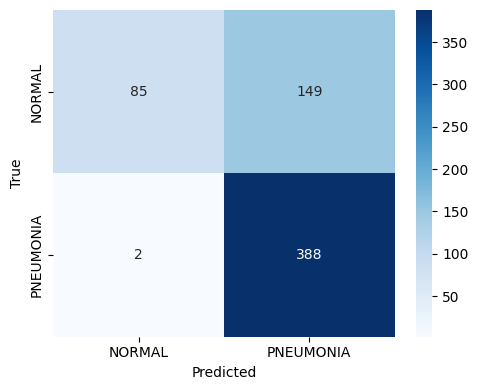

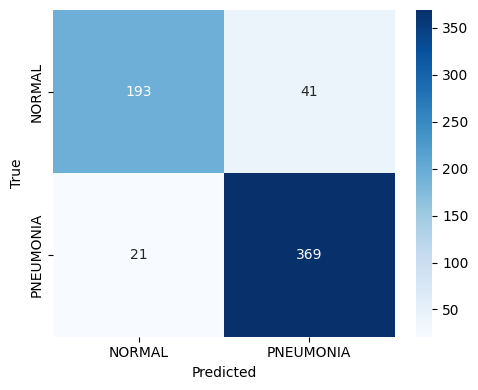

In [25]:
# Confusion matrices: true vs predicted classes for both models.
plot_confusion_matrix("HOG + SVM", y_test, svm_pred, save_path="svm_confusion.png")
plot_confusion_matrix("ResNet50", y_test_cnn, cnn_pred, save_path="cnn_confusion.png")


## 10. Threshold sweep


 threshold  pneumonia_recall  normal_recall  macro_f1  false_positives  false_negatives
      0.05            0.9923         0.5641    0.7980              102                3
      0.10            0.9897         0.6239    0.8270               88                4
      0.15            0.9769         0.6667    0.8397               78                9
      0.20            0.9718         0.7094    0.8567               68               11
      0.25            0.9667         0.7564    0.8750               57               13
      0.30            0.9641         0.7821    0.8848               51               14
      0.35            0.9615         0.7949    0.8888               48               15
      0.40            0.9590         0.8162    0.8966               43               16
      0.45            0.9538         0.8205    0.8951               42               18
      0.50            0.9462         0.8248    0.8921               41               21
      0.55            0.9462    

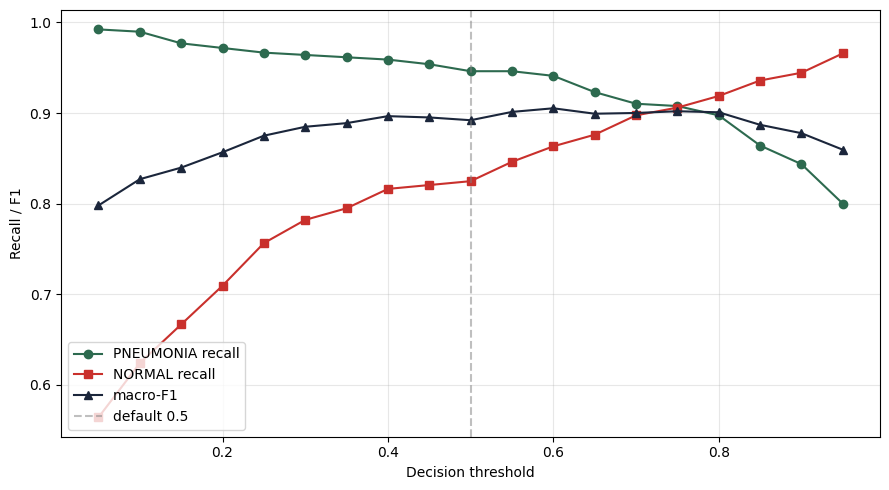

In [26]:
# Try a range of probability thresholds to see how recall and false alarm rate move.
thresholds = np.round(np.arange(0.05, 0.96, 0.05), 2)
sweep_rows = []
for t in thresholds:
    pred = (cnn_proba >= t).astype(int)
    cm = confusion_matrix(y_test_cnn, pred)
    sweep_rows.append({
        "threshold": t,
        "pneumonia_recall":   recall_score(y_test_cnn, pred, pos_label=1, zero_division=0),
        "normal_recall":      recall_score(y_test_cnn, pred, pos_label=0, zero_division=0),
        "macro_f1":           f1_score(y_test_cnn, pred, average="macro", zero_division=0),
        "false_positives":    int(cm[0, 1]) if cm.shape == (2, 2) else 0,
        "false_negatives":    int(cm[1, 0]) if cm.shape == (2, 2) else 0,
    })
sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df.round(4).to_string(index=False))

# Line chart of the threshold range for visualisation.
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sweep_df["threshold"], sweep_df["pneumonia_recall"], marker="o",
        color="#2D6A4F", label="PNEUMONIA recall")
ax.plot(sweep_df["threshold"], sweep_df["normal_recall"], marker="s",
        color="#C9302C", label="NORMAL recall")
ax.plot(sweep_df["threshold"], sweep_df["macro_f1"], marker="^",
        color="#1B263B", label="macro-F1")
ax.axvline(0.5, linestyle="--", color="grey", alpha=0.5, label="default 0.5")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Recall / F1")
ax.legend(loc="lower left"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("threshold_recall_f1.png", dpi=180, bbox_inches="tight")
plt.show()


## 11. SVM explainability


Correct PNEUMONIA at index 234, misclassified at index 0
  Correct PNEUMONIA: baseline P(PNEUMONIA) = 1.0000
  Correct PNEUMONIA: 64 patches, heatmap range [-0.0000, 0.0055], 1.4s
  Misclassified: baseline P(PNEUMONIA) = 0.9498
  Misclassified: 64 patches, heatmap range [-0.0274, 0.0514], 1.4s


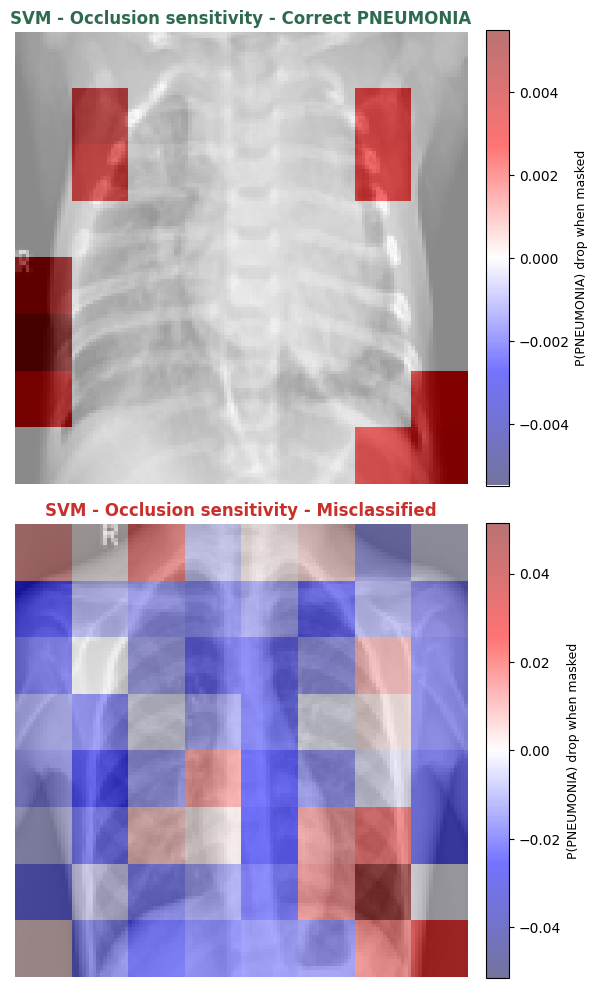

In [27]:
# Run occlusion sensitivity on two SVM cases, one right and one wrong: measure how much SVM probability drops and produce a heatmap based on it.

# Find two test images: one the SVM got right, one it got wrong.
idx_correct = int(np.where((svm_pred == y_test) & (y_test == 1))[0][0])
idx_wrong   = int(np.where(svm_pred != y_test)[0][0])
print(f"Correct PNEUMONIA at index {idx_correct}, misclassified at index {idx_wrong}")

# Non-overlapping occlusion windows: stride equals patch size, so every pixel is covered exactly once.
OCC_PATCH  = 16
OCC_STRIDE = 16

fig, axes = plt.subplots(2, 1, figsize=(6, 10))

for row_i, (idx, title) in enumerate([(idx_correct, "Correct PNEUMONIA"),
                                      (idx_wrong,   "Misclassified")]):
    # Use the same preprocessing the SVM saw during training: grayscale, PIL resize, /255.
    img_path = test_df["path"].iloc[idx]
    img_gray = Image.open(img_path).convert("L").resize((HOG_SIZE, HOG_SIZE))
    img_gray = np.array(img_gray) / 255.0

    # HOG feature baseline.
    feat = hog(
        img_gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True,
    )

    # Occlusion loop: mask each non-overlapping patch in turn and record the SVM confidence drop.
    baseline_feat = feat.reshape(1, -1).astype(np.float32)
    baseline_proba = svm.predict_proba(scaler.transform(baseline_feat))[0, 1]
    print(f"  {title}: baseline P(PNEUMONIA) = {baseline_proba:.4f}")

    H = W = HOG_SIZE
    heatmap = np.zeros((H, W), dtype=np.float32)
    n_patches = 0
    t0 = time.time()
    for y_top in range(0, H - OCC_PATCH + 1, OCC_STRIDE):
        for x_left in range(0, W - OCC_PATCH + 1, OCC_STRIDE):
            masked = img_gray.copy()
            masked[y_top:y_top + OCC_PATCH,
                   x_left:x_left + OCC_PATCH] = 0.0
            masked_feat = hog(
                masked,
                orientations=9,
                pixels_per_cell=(8, 8),
                cells_per_block=(2, 2),
                block_norm="L2-Hys",
                feature_vector=True,
            ).reshape(1, -1).astype(np.float32)
            masked_proba = svm.predict_proba(scaler.transform(masked_feat))[0, 1]
            drop = baseline_proba - masked_proba
            heatmap[y_top:y_top + OCC_PATCH,
                    x_left:x_left + OCC_PATCH] = drop
            n_patches += 1
    print(f"  {title}: {n_patches} patches, "
          f"heatmap range [{heatmap.min():.4f}, {heatmap.max():.4f}], "
          f"{time.time() - t0:.1f}s")

    ax_occ = axes[row_i]
    ax_occ.imshow(img_gray, cmap="gray")
    im = ax_occ.imshow(heatmap, cmap="seismic",
                       vmin=-abs(heatmap).max(), vmax=abs(heatmap).max(),
                       alpha=0.55)
    border = "#2D6A4F" if "Correct" in title else "#C9302C"
    ax_occ.set_title(f"SVM - Occlusion sensitivity - {title}", color=border, weight="bold")
    ax_occ.axis("off")
    cbar = plt.colorbar(im, ax=ax_occ, fraction=0.046, pad=0.04)
    cbar.set_label("P(PNEUMONIA) drop when masked", fontsize=9)

plt.tight_layout()
plt.savefig("xai_svm.png", dpi=180, bbox_inches="tight")
plt.show()


## 12. CNN explainability


Correct PNEUMONIA at index 235, misclassified at index 16
  Correct PNEUMONIA: baseline P(PNEUMONIA) = 0.9999
  Correct PNEUMONIA: 49 patches, heatmap range [-0.0000, 0.0039], 4.0s
  Misclassified: baseline P(PNEUMONIA) = 0.9965
  Misclassified: 49 patches, heatmap range [-0.0030, 0.0355], 4.0s


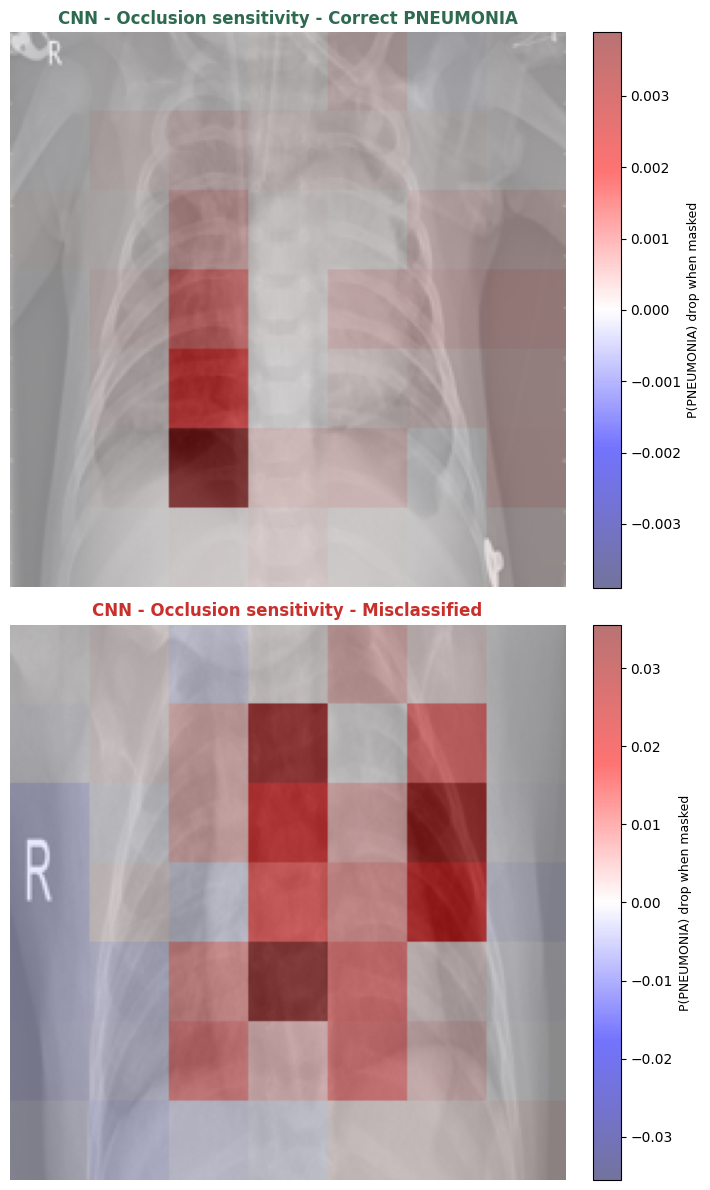

In [28]:
# Same occlusion sensitivity as on the SVM, now applied to the CNN.

idx_correct = int(np.where((cnn_pred == y_test_cnn) & (y_test_cnn == 1))[0][0])
idx_wrong   = int(np.where(cnn_pred != y_test_cnn)[0][0])
print(f"Correct PNEUMONIA at index {idx_correct}, misclassified at index {idx_wrong}")

# Non-overlapping occlusion windows: stride equals patch size, so every pixel is covered exactly once.
OCC_CNN_PATCH  = 32
OCC_CNN_STRIDE = 32

fig, axes = plt.subplots(2, 1, figsize=(8, 12))

for row_i, (idx, title) in enumerate([(idx_correct, "Correct PNEUMONIA"),
                                      (idx_wrong,   "Misclassified")]):
    img_pil = Image.open(test_df["path"].iloc[idx]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    img_uint8 = np.array(img_pil)

    baseline_batch = preprocess_input(np.expand_dims(img_uint8.astype(np.float32), axis=0))
    baseline_proba = float(cnn.predict(baseline_batch, verbose=0)[0, 0])
    print(f"  {title}: baseline P(PNEUMONIA) = {baseline_proba:.4f}")

    H = W = IMG_SIZE
    heatmap = np.zeros((H, W), dtype=np.float32)
    n_patches = 0
    t0 = time.time()
    for y_top in range(0, H - OCC_CNN_PATCH + 1, OCC_CNN_STRIDE):
        for x_left in range(0, W - OCC_CNN_PATCH + 1, OCC_CNN_STRIDE):
            masked_uint8 = img_uint8.copy()
            masked_uint8[y_top:y_top + OCC_CNN_PATCH,
                         x_left:x_left + OCC_CNN_PATCH, :] = 128
            masked_batch = preprocess_input(np.expand_dims(masked_uint8.astype(np.float32), axis=0))
            masked_proba = float(cnn.predict(masked_batch, verbose=0)[0, 0])
            drop = baseline_proba - masked_proba
            heatmap[y_top:y_top + OCC_CNN_PATCH,
                    x_left:x_left + OCC_CNN_PATCH] = drop
            n_patches += 1
    print(f"  {title}: {n_patches} patches, "
          f"heatmap range [{heatmap.min():.4f}, {heatmap.max():.4f}], "
          f"{time.time() - t0:.1f}s")

    ax = axes[row_i]
    ax.imshow(img_uint8)
    im = ax.imshow(heatmap, cmap="seismic",
                   vmin=-abs(heatmap).max(), vmax=abs(heatmap).max(),
                   alpha=0.55)
    border = "#2D6A4F" if "Correct" in title else "#C9302C"
    ax.set_title(f"CNN - Occlusion sensitivity - {title}", color=border, weight="bold")
    ax.axis("off")
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("P(PNEUMONIA) drop when masked", fontsize=9)

plt.tight_layout()
plt.savefig("xai_cnn.png", dpi=180, bbox_inches="tight")
plt.show()


## 13. Subgroup analysis


In [29]:
# Compute per-subgroup metrics to check for bias across disease subtype, brightness and image size.

diag = test_df.copy().reset_index(drop=True)
diag["svm_pred"] = svm_pred
diag["cnn_pred"] = cnn_pred[:len(diag)]
diag["luminance"] = [float(np.array(Image.open(p).convert("L")).mean())
                     for p in diag["path"]]
diag["pixels"]    = [Image.open(p).size[0] * Image.open(p).size[1]
                     for p in diag["path"]]
diag["lum_bin"]  = pd.qcut(diag["luminance"], 3, labels=["low", "mid", "high"])
diag["size_bin"] = pd.qcut(diag["pixels"],    3, labels=["small", "mid", "large"])
subtypes = []
for p in diag["path"]:
    if "virus" in Path(p).name.lower():
        subtypes.append("viral")
    else:
        subtypes.append("bacterial")
diag["subtype"] = subtypes

rows = []

# Split by disease subtype (bacterial vs viral, inferred from the filename) and compute metrics on each subset.
for sub, df_g in diag[diag.label == 1].groupby("subtype"):
    rows.append(compute_subgroup_metrics(df_g, f"PNEU subtype: {sub}"))

# Bias test but this time on brightness level.
for binname, df_g in diag.groupby("lum_bin"):
    rows.append(compute_subgroup_metrics(df_g, f"Brightness: {binname}"))

# Third bias test, this time on image size.
for binname, df_g in diag.groupby("size_bin"):
    rows.append(compute_subgroup_metrics(df_g, f"Image size: {binname}"))

subgroup_df = pd.DataFrame(rows)
print(subgroup_df.round(4).to_string(index=False))


               Subgroup   n  SVM macro-F1  CNN macro-F1  SVM PNEU recall  CNN PNEU recall
PNEU subtype: bacterial 242        0.4990        0.4862           0.9959           0.9463
    PNEU subtype: viral 148        0.4983        0.4861           0.9932           0.9459
        Brightness: low 208        0.7389        0.8950           0.9930           0.9231
        Brightness: mid 208        0.6883        0.9358           1.0000           0.9850
       Brightness: high 208        0.6283        0.8466           0.9912           0.9298
      Image size: small 209        0.4952        0.6964           1.0000           1.0000
        Image size: mid 207        0.5589        0.7660           0.9936           0.9108
      Image size: large 208        0.4731        0.7776           0.9643           0.7500


/tmp/ipykernel_922/3189413204.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for binname, df_g in diag.groupby("lum_bin"):
/tmp/ipykernel_922/3189413204.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for binname, df_g in diag.groupby("size_bin"):


## 14. Demonstration


In [30]:
# Demo as per assignment

from pathlib import Path
import numpy as np
from PIL import Image
from skimage import transform
from skimage.feature import hog
from tensorflow.keras.applications.resnet50 import preprocess_input

# Load both saved models from Drive (fast - they are already trained).
svm    = joblib.load(MODEL_ASSETS_OUTPUT / "svm_rbf_v3.pkl")
scaler = joblib.load(MODEL_ASSETS_OUTPUT / "scaler_v3.pkl")
cnn    = load_model(MODEL_ASSETS_OUTPUT / "cnn_resnet50_v3.keras")

# The held-out NORMAL X-ray we will run both models on.
DEMO_IMAGE = DRIVE_BASE / "demo_image.jpeg"
print(f"Demo image: {DEMO_IMAGE.name}")
print(f"True label: NORMAL")
print()

# Run the complete SVM on the image for demo (preprocess, HOG, scale, predict).
# Preprocessing matching the training: PIL grayscale, resize to 128, divide by 255.
img_gray = Image.open(DEMO_IMAGE).convert("L").resize((128, 128))
img_gray = np.array(img_gray) / 255.0
hog_feat = hog(img_gray, orientations=9, pixels_per_cell=(8, 8),
               cells_per_block=(2, 2), block_norm="L2-Hys", feature_vector=True)
svm_prob = svm.predict_proba(scaler.transform(hog_feat.reshape(1, -1)))[0, 1]

# Run the complete CNN on the image for demo (preprocess, predict).
img_rgb = np.array(Image.open(DEMO_IMAGE).convert("RGB").resize((224, 224)))
batch = preprocess_input(np.expand_dims(img_rgb.astype(np.float32), axis=0))
cnn_prob = float(cnn.predict(batch, verbose=0)[0, 0])

if svm_prob >= 0.5:
    svm_label = "PNEUMONIA"
else:
    svm_label = "NORMAL"

if cnn_prob >= 0.5:
    cnn_label = "PNEUMONIA"
else:
    cnn_label = "NORMAL"

print(f"SVM:  P(PNEUMONIA) = {svm_prob:.4f}  ->  {svm_label}")
print(f"CNN:  P(PNEUMONIA) = {cnn_prob:.4f}  ->  {cnn_label}")
print(f"True label: NORMAL")


Demo image: demo_image.jpeg
True label: NORMAL

SVM:  P(PNEUMONIA) = 0.8343  ->  PNEUMONIA
CNN:  P(PNEUMONIA) = 0.0510  ->  NORMAL
True label: NORMAL


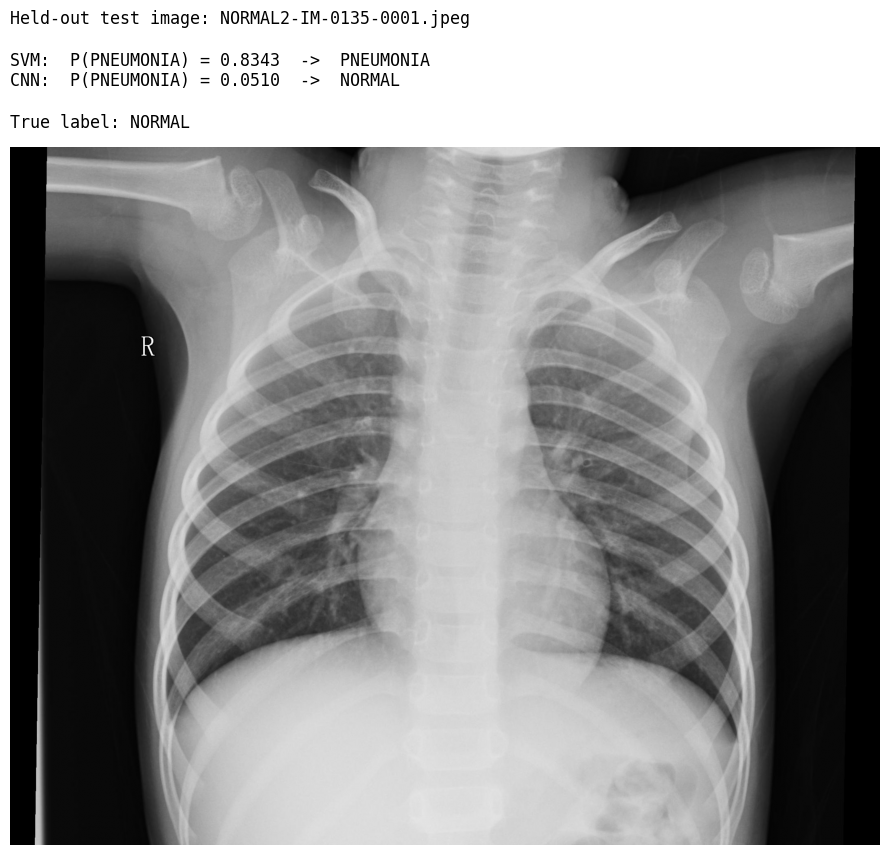

In [31]:
# Render the demo image plus SVM and CNN predictions.
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(9, 9))
ax.imshow(Image.open(DEMO_IMAGE), cmap="gray")
ax.axis("off")
ax.set_title(
    f"Held-out test image: NORMAL2-IM-0135-0001.jpeg\n\n"
    f"SVM:  P(PNEUMONIA) = {svm_prob:.4f}  ->  {svm_label}\n"
    f"CNN:  P(PNEUMONIA) = {cnn_prob:.4f}  ->  {cnn_label}\n\n"
    f"True label: NORMAL",
    fontsize=12,
    loc="left",
    pad=14,
    family="monospace"
)
plt.tight_layout()
plt.show()
